# Setup and Environment

This section mounts Google Drive and initializes the environment for accessing the dataset.

In [20]:
from google.colab import drive
drive.mount('/content/drive')
import os

base_path = "/content/drive/MyDrive/iemocap"
print(os.listdir(base_path))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
['IEMOCAP_full_release']


# Data Loading and Directory Structure

This section defines the dataset path and inspects the directory structure to ensure the IEMOCAP data is correctly loaded.

In [21]:
import os

base_path = "/content/drive/MyDrive/iemocap/IEMOCAP_full_release"

# List contents of dataset folder
for item in os.listdir(base_path):
    print(item)

README.txt~
README.txt
.DS_Store
Session5
Session1
Session2
Documentation
Session3
Session4


In [22]:
import os
import pandas as pd

base_path = "/content/drive/MyDrive/iemocap/IEMOCAP_full_release"

# Check main dataset structure
print("Main directory contents:")
print(os.listdir(base_path))

# Inspect Session1 dialog folder
session1_dialog = os.path.join(base_path, "Session1", "dialog")
print("\nSession1 dialog contents:")
print(os.listdir(session1_dialog))

# Inspect EmoEvaluation files
emo_path = os.path.join(session1_dialog, "EmoEvaluation")
files = os.listdir(emo_path)

print("\nSample annotation file:")
print(files[0])

# Check all sessions
print("\nAll session dialog folders:")
sessions = [f"Session{i}" for i in range(1, 6)]

for session in sessions:
    dialog_path = os.path.join(base_path, session, "dialog")
    print(f"{session}:", os.listdir(dialog_path))

Main directory contents:
['README.txt~', 'README.txt', '.DS_Store', 'Session5', 'Session1', 'Session2', 'Documentation', 'Session3', 'Session4']

Session1 dialog contents:
['.DS_Store', 'MOCAP_hand', 'transcriptions', 'EmoEvaluation', 'lab', 'MOCAP_rotated', 'wav', 'MOCAP_head', 'avi']

Sample annotation file:
Ses01F_script02_1.txt

All session dialog folders:
Session1: ['.DS_Store', 'MOCAP_hand', 'transcriptions', 'EmoEvaluation', 'lab', 'MOCAP_rotated', 'wav', 'MOCAP_head', 'avi']
Session2: ['MOCAP_hand', 'transcriptions', 'lab', 'EmoEvaluation', 'avi', 'MOCAP_rotated', 'MOCAP_head', 'wav']
Session3: ['MOCAP_hand', 'avi', 'lab', 'MOCAP_rotated', 'transcriptions', 'wav', 'EmoEvaluation', 'MOCAP_head']
Session4: ['MOCAP_hand', 'lab', 'EmoEvaluation', 'transcriptions', 'MOCAP_rotated', 'avi', 'MOCAP_head', 'wav']
Session5: ['MOCAP_hand', 'transcriptions', 'EmoEvaluation', 'lab', 'wav', 'avi', 'MOCAP_rotated', 'MOCAP_head']


# Annotation

In [23]:
with open(os.path.join(emo_path, files[0]), "r") as f:
    for line in f:
        if line.startswith("["):
            print(line)
            break

[15.1400 - 17.2100]	Ses01F_script02_1_F000	neu	[2.5000, 2.0000, 2.0000]



In [24]:
line = "[15.1400 - 17.2100]\tSes01F_script02_1_F000\tneu\t[2.5000, 2.0000, 2.0000]"

parts = line.strip().split("\t")

print(parts)

['[15.1400 - 17.2100]', 'Ses01F_script02_1_F000', 'neu', '[2.5000, 2.0000, 2.0000]']


In [25]:
utterance_id = parts[1]
emotion = parts[2]

print(utterance_id, emotion)

Ses01F_script02_1_F000 neu


# Parsing Emotion Annotations

This section extracts utterance IDs and emotion labels from all IEMOCAP annotation files and stores them in a structured dataframe.

In [26]:
import os
import pandas as pd
import re

base_path = "/content/drive/MyDrive/iemocap/IEMOCAP_full_release"

data = []

sessions = [f"Session{i}" for i in range(1, 6)]

for session in sessions:
    emo_path = os.path.join(base_path, session, "dialog", "EmoEvaluation")

    for file in os.listdir(emo_path):
        file_path = os.path.join(emo_path, file)

        # Check if it's a file before attempting to open it
        if os.path.isfile(file_path):
            # Open file with utf-8 encoding and ignore errors
            with open(file_path, "r", encoding="utf-8", errors="ignore") as f:
                for line in f:

                    # Match lines like:
                    # [start - end]  utterance_id emotion [V, A, D]
                    match = re.match(r"\[.*\]\s+(\S+)\s+(\S+)\s+\[", line)

                    if match:
                        utterance_id = match.group(1)
                        emotion = match.group(2)

                        # Keep only main emotions
                        if emotion in ["ang", "hap", "sad", "neu"]:
                            data.append([utterance_id, emotion])

# Create DataFrame
df = pd.DataFrame(data, columns=["utterance_id", "emotion"])

print(df.head())
print("\nCounts:")
print(df["emotion"].value_counts())
print(df.head())

             utterance_id emotion
0  Ses01F_script02_1_F000     neu
1  Ses01F_script02_1_F004     neu
2  Ses01F_script02_1_F006     ang
3  Ses01F_script02_1_F007     ang
4  Ses01F_script02_1_F008     neu

Counts:
emotion
neu    1708
ang    1103
sad    1084
hap     595
Name: count, dtype: int64
             utterance_id emotion
0  Ses01F_script02_1_F000     neu
1  Ses01F_script02_1_F004     neu
2  Ses01F_script02_1_F006     ang
3  Ses01F_script02_1_F007     ang
4  Ses01F_script02_1_F008     neu


In [27]:
df = pd.DataFrame(data, columns=["utterance_id", "emotion"])

df = df[df["emotion"].isin(["ang", "hap", "sad", "neu"])]

print("Final dataset size:", len(df))

Final dataset size: 4490


# Transcript Parsing

This section extracts transcripts from IEMOCAP files and maps them to utterance IDs for multimodal analysis.

In [28]:
import os

transcripts = {}

sessions = [f"Session{i}" for i in range(1, 6)]

for session in sessions:
    trans_path = os.path.join(
        base_path,
        session,
        "dialog",
        "transcriptions"
    )

    for file in os.listdir(trans_path):
        file_path = os.path.join(trans_path, file)

        with open(file_path, "r") as f:
            for line in f:

                # Only process valid lines
                if ":" in line:
                    try:
                        parts = line.strip().split(":")
                        left = parts[0]
                        text = parts[1].strip()

                        # Extract utterance ID (first token)
                        utterance_id = left.split()[0]

                        transcripts[utterance_id] = text

                    except:
                        continue

print("Sample transcript:")
for k in list(transcripts.keys())[:5]:
    print(k, "->", transcripts[k])

Sample transcript:
Ses01M_script01_2_F000 -> Why did he invite her here?
Ses01M_script01_2_M000 -> Well, maybe he wanted see her.
Ses01M_script01_2_F001 -> It's been three and a half years.  Why all of a sudden?
Ses01M_script01_2_M001 -> Well uh, He grew up next door to the girl, why wouldn't he want to see her?
Ses01M_script01_2_M002 -> Don't look at me like that.  He didn't tell me anything he told you.


In [29]:
df["transcript"] = df["utterance_id"].map(transcripts)

# Drop missing values (important)
df = df.dropna()

print(df.head())
print("\nFinal dataset size:", len(df))

             utterance_id emotion  \
0  Ses01F_script02_1_F000     neu   
1  Ses01F_script02_1_F004     neu   
2  Ses01F_script02_1_F006     ang   
3  Ses01F_script02_1_F007     ang   
4  Ses01F_script02_1_F008     neu   

                                          transcript  
0                                              Fine.  
1                        That's not your flashlight.  
2  You keep saying my flashlight like it's just y...  
3               How's that supposed to make me feel?  
4                                              Yeah.  

Final dataset size: 4490


In [30]:
print(df.isnull().sum())

utterance_id    0
emotion         0
transcript      0
dtype: int64


# Text Feature Extraction

This section converts transcripts into numerical representations using TF-IDF to capture lexical patterns.

In [31]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Initialize vectorizer
vectorizer = TfidfVectorizer(max_features=1000)

# Fit and transform transcripts
X_text = vectorizer.fit_transform(df["transcript"])

print("Text feature shape:", X_text.shape)

Text feature shape: (4490, 1000)


# Audio Feature Extraction

This section extracts acoustic features (MFCCs, energy, and zero-crossing rate) for each utterance by mapping utterance IDs to their corresponding audio files.

In [35]:
pip install soundfile

In [38]:
def find_wav_path(base_path, utterance_id):
    session = utterance_id[:5]  # e.g., Ses01
    session_folder = "Session" + session[-1]  # Session1

    wav_root = os.path.join(base_path, session_folder, "sentences", "wav")

    for root, dirs, files in os.walk(wav_root):
        for file in files:
            if file.startswith(utterance_id):
                return os.path.join(root, file)

    return None

In [39]:
import librosa
import numpy as np
import os
import soundfile # Added this line

def extract_features(file_path):
    try:
        y, sr = librosa.load(file_path, sr=None)

        mfcc = np.mean(librosa.feature.mfcc(y=y, sr=sr, n_mfcc=13), axis=1)
        energy = np.mean(y**2)
        zcr = np.mean(librosa.feature.zero_crossing_rate(y))

        return np.hstack([mfcc, energy, zcr])

    except:
        return None

audio_features = []
valid_indices = []

for i, row in df.iterrows():
    utt_id = row["utterance_id"]

    wav_path = find_wav_path(base_path, utt_id)

    if wav_path is not None:
        features = extract_features(wav_path)

        if features is not None:
            audio_features.append(features)
            valid_indices.append(i)

/tmp/ipykernel_10171/3921400150.py:8: UserWarning: PySoundFile failed. Trying audioread instead.
  y, sr = librosa.load(file_path, sr=None)
/usr/local/lib/python3.12/dist-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)


In [33]:
# Keep only rows with valid audio
df_audio = df.iloc[valid_indices].reset_index(drop=True)

X_audio = np.array(audio_features)

print("Audio feature shape:", X_audio.shape)
print("Filtered dataset size:", len(df_audio))

Audio feature shape: (4489, 15)
Filtered dataset size: 4489


# Model Training

This section trains three models to compare the contribution of lexical and acoustic features:
1. Text-only model
2. Audio-only model
3. Combined model (early fusion)

In [40]:
from sklearn.model_selection import train_test_split

# Labels
y = df_audio["emotion"]

# Convert sparse TF-IDF to array
X_text_dense = X_text[df_audio.index].toarray()

# Combined features
X_combined = np.hstack([X_audio, X_text_dense])

# Train-test split (same split for all models)
X_train_text, X_test_text, y_train, y_test = train_test_split(
    X_text_dense, y, test_size=0.2, random_state=42
)

X_train_audio, X_test_audio, _, _ = train_test_split(
    X_audio, y, test_size=0.2, random_state=42
)

X_train_comb, X_test_comb, _, _ = train_test_split(
    X_combined, y, test_size=0.2, random_state=42
)

In [41]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

text_model = LogisticRegression(max_iter=1000)
text_model.fit(X_train_text, y_train)

y_pred_text = text_model.predict(X_test_text)

print("TEXT MODEL")
print(classification_report(y_test, y_pred_text))

TEXT MODEL
              precision    recall  f1-score   support

         ang       0.65      0.61      0.63       222
         hap       0.59      0.25      0.35       119
         neu       0.59      0.73      0.65       343
         sad       0.58      0.57      0.58       214

    accuracy                           0.60       898
   macro avg       0.60      0.54      0.55       898
weighted avg       0.60      0.60      0.59       898



In [42]:
audio_model = LogisticRegression(max_iter=1000)
audio_model.fit(X_train_audio, y_train)

y_pred_audio = audio_model.predict(X_test_audio)

print("AUDIO MODEL")
print(classification_report(y_test, y_pred_audio))

AUDIO MODEL
              precision    recall  f1-score   support

         ang       0.72      0.75      0.73       222
         hap       0.33      0.03      0.06       119
         neu       0.56      0.67      0.61       343
         sad       0.56      0.64      0.60       214

    accuracy                           0.60       898
   macro avg       0.54      0.52      0.50       898
weighted avg       0.57      0.60      0.56       898



/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [43]:
combined_model = LogisticRegression(max_iter=1000)
combined_model.fit(X_train_comb, y_train)

y_pred_combined = combined_model.predict(X_test_comb)

print("COMBINED MODEL")
print(classification_report(y_test, y_pred_combined))

COMBINED MODEL
              precision    recall  f1-score   support

         ang       0.74      0.80      0.77       222
         hap       0.73      0.23      0.35       119
         neu       0.64      0.71      0.67       343
         sad       0.62      0.69      0.65       214

    accuracy                           0.66       898
   macro avg       0.68      0.61      0.61       898
weighted avg       0.67      0.66      0.65       898



/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [44]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_combined_scaled = scaler.fit_transform(X_combined)

combined_model = LogisticRegression(max_iter=2000)
combined_model.fit(X_combined_scaled, y)

LogisticRegression(max_iter=2000)

# Confusion Matrix

This section visualizes the performance of the combined model across emotion categories, highlighting common misclassifications.

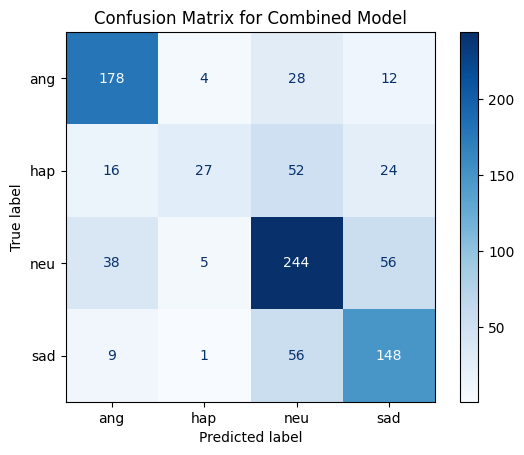

In [45]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Create confusion matrix
cm = confusion_matrix(y_test, y_pred_combined, labels=["ang", "hap", "neu", "sad"])

# Display
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["ang", "hap", "neu", "sad"])
disp.plot(cmap=plt.cm.Blues)

plt.title("Confusion Matrix for Combined Model")
plt.show()

# Statistical Analysis

This section evaluates whether differences in model performance are statistically significant.

In [47]:
import numpy as np
import pandas as pd

# Convert predictions to accuracy per sample (correct = 1, wrong = 0)

text_correct = (y_pred_text == y_test).astype(int)
audio_correct = (y_pred_audio == y_test).astype(int)
combined_correct = (y_pred_combined == y_test).astype(int)

# Create dataframe
results_df = pd.DataFrame({
    "text": text_correct,
    "audio": audio_correct,
    "combined": combined_correct
})

print(results_df.head())

      text  audio  combined
157      0      0         0
4247     0      0         1
1020     1      1         1
1119     0      0         0
731      0      0         0


In [48]:
from scipy.stats import f_oneway

anova = f_oneway(
    results_df["text"],
    results_df["audio"],
    results_df["combined"]
)

print("ANOVA F-statistic:", anova.statistic)
print("ANOVA p-value:", anova.pvalue)

ANOVA F-statistic: 5.609116231511043
ANOVA p-value: 0.0037072793862822522


In [49]:
from scipy.stats import ttest_rel

t_text_audio = ttest_rel(results_df["text"], results_df["audio"])
t_text_combined = ttest_rel(results_df["text"], results_df["combined"])
t_audio_combined = ttest_rel(results_df["audio"], results_df["combined"])

print("Text vs Audio:", t_text_audio)
print("Text vs Combined:", t_text_combined)
print("Audio vs Combined:", t_audio_combined)

Text vs Audio: TtestResult(statistic=np.float64(0.15869063429410474), pvalue=np.float64(0.8739483373161796), df=np.int64(897))
Text vs Combined: TtestResult(statistic=np.float64(-3.5525325006724517), pvalue=np.float64(0.00040142417434066874), df=np.int64(897))
Audio vs Combined: TtestResult(statistic=np.float64(-4.691688748253991), pvalue=np.float64(3.131735461443843e-06), df=np.int64(897))


In [50]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

# Scale combined features
scaler = StandardScaler()
X_combined_scaled = scaler.fit_transform(X_combined)

# Train regression model
reg_model = LogisticRegression(max_iter=2000)
reg_model.fit(X_combined_scaled, y)

# Get coefficients
coefficients = pd.DataFrame(
    reg_model.coef_,
    columns=[f"feat_{i}" for i in range(X_combined.shape[1])]
)

print(coefficients.head())

     feat_0    feat_1    feat_2    feat_3    feat_4    feat_5    feat_6  \
0  0.807817 -1.125674  0.068417 -0.641592 -0.118092 -0.352000  0.328502   
1  0.247534 -0.605172 -0.684626  0.221063 -0.243786 -0.056656 -0.197799   
2 -0.028659  1.104962 -0.117250  0.189149  0.002994 -0.000503 -0.188189   
3 -1.026692  0.625884  0.733460  0.231380  0.358884  0.409159  0.057486   

     feat_7    feat_8    feat_9  ...  feat_1005  feat_1006  feat_1007  \
0 -0.445703 -0.188545 -0.276069  ...   0.041351  -0.227617   0.192940   
1 -0.237789  0.199056  0.377465  ...  -0.545446  -0.368712  -0.074720   
2  0.121565  0.031475 -0.041016  ...   0.238405  -0.120230   0.012521   
3  0.561928 -0.041986 -0.060381  ...   0.265690   0.716560  -0.130741   

   feat_1008  feat_1009  feat_1010  feat_1011  feat_1012  feat_1013  feat_1014  
0   0.225276   0.325247   0.228425  -0.061128   0.149450   0.070944   0.319315  
1  -0.125046  -0.089701  -0.017918  -0.010601  -0.102489   0.150873  -0.085284  
2   0.086735  -

In [52]:
from collections import Counter
words = " ".join(df["transcript"].astype(str)).lower().split()
Counter(words).most_common(20)

[('i', 2338),
 ('you', 2080),
 ('to', 1360),
 ('and', 1018),
 ('the', 1016),
 ('a', 917),
 ('of', 623),
 ('it', 617),
 ('that', 608),
 ("it's", 478),
 ('just', 448),
 ("don't", 448),
 ('like', 444),
 ('have', 440),
 ('in', 379),
 ('is', 373),
 ('know', 373),
 ('what', 372),
 ('for', 371),
 ('do', 369)]

In [53]:
df["length"] = df["transcript"].apply(lambda x: len(str(x).split()))
df.groupby("emotion")["length"].mean()

,length
emotion,
ang,12.640979
hap,10.396639
neu,10.131148
sad,11.873616


In [54]:
df["emotion"].value_counts()

,count
emotion,
neu,1708
ang,1103
sad,1084
hap,595


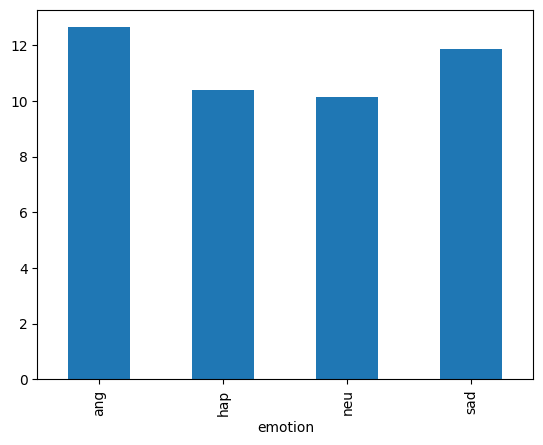

In [55]:
df.groupby("emotion")["length"].mean().plot(kind="bar")
plt.show()